In [1]:
import pandas as pd

Grouping drivers based on mean distance driven per day and mean over-speed %

For the sake of simplicity, take only two features:

mean distance has driven per day
the mean percentage of time a driver was >5 mph over the speed limit
Here are what the data represent:

id: Unique Id of the driver
mean_dist_day: Mean distance driven by driver per day
mean_over_speed_perc: Mean percentage of time a driver was > 5 mph over the speed limit

In [17]:
df = pd.read_csv("driver-data.csv", index_col="id")
df.head()

,mean_dist_day,mean_over_speed_perc
id,,
3423311935,71.24,28
3423313212,52.53,25
3423313724,64.54,27
3423311373,55.69,22
3423310999,54.58,25


In [18]:
from sklearn.cluster import KMeans

In [19]:
kmeans = KMeans(n_clusters=4)

In [20]:
kmeans.fit(df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=4)

In [21]:
kmeans.cluster_centers_

array([[ 50.46127059,  32.42823529],
       [180.34311782,  10.52011494],
       [ 49.98428468,   5.21441441],
       [177.83509615,  70.28846154]])

In [22]:
kmeans.labels_

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [23]:
import numpy as np

In [24]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)

In [25]:
dict_data = dict(zip(unique, counts))
dict_data

{0: 425, 1: 696, 2: 2775, 3: 104}

In [26]:
import seaborn as sns

In [27]:
df["cluster"] = kmeans.labels_

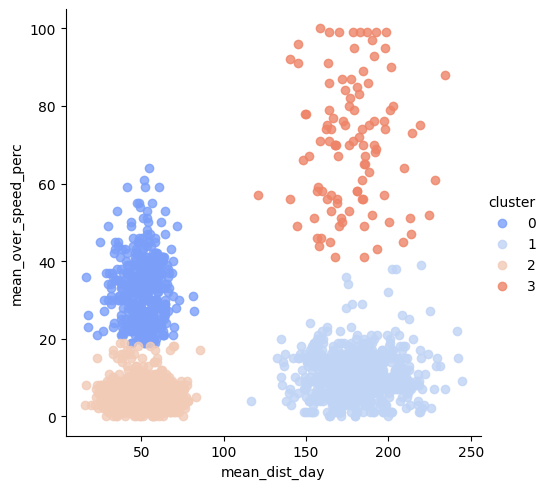

In [35]:
sns.lmplot(x = 'mean_dist_day', y = 'mean_over_speed_perc', data = df, hue='cluster', palette='coolwarm',fit_reg = False)

In [36]:
# Inertia is the sum of squared error for each cluster.
# Therefore the smaller the inertia the denser the cluster(closer together all the points are)

kmeans.inertia_

719601.5383469043

In [37]:
kmeans.score

<bound method _BaseKMeans.score of KMeans(n_clusters=4)>

In [39]:
df

,mean_dist_day,mean_over_speed_perc,cluster
id,,,
3423311935,71.24,28,0
3423313212,52.53,25,0
3423313724,64.54,27,0
3423311373,55.69,22,0
3423310999,54.58,25,0
...,...,...,...
3423310685,160.04,10,1
3423312600,176.17,5,1
3423312921,170.91,12,1


from matplotlib import pyplot as plt
df['mean_dist_day'].plot(kind='hist', bins=20, title='mean_dist_day')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['mean_over_speed_perc'].plot(kind='hist', bins=20, title='mean_over_speed_perc')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['cluster'].plot(kind='hist', bins=20, title='cluster')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='mean_dist_day', y='mean_over_speed_perc', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='mean_over_speed_perc', y='cluster', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['mean_dist_day'].plot(kind='line', figsize=(8, 4), title='mean_dist_day')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['mean_over_speed_perc'].plot(kind='line', figsize=(8, 4), title='mean_over_speed_perc')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['cluster'].plot(kind='line', figsize=(8, 4), title='cluster')
plt.gca().spines[['top', 'right']].set_visible(False)